# dependencies: papermill and scrapbook

In [1]:
!ls
!pip install scrapbook
!pip install papermill
!pip install adjustText

Ag_Plot_Test_Protocol.ipynb	Zpdf_comparison.zip
MBMF_rampdown_ag14100.png	Zpds_three_segments_ag14100.png
MBMF_rampdown_ag14106.png	Zpds_three_segments_ag14100.tar
MBMF_rampdown_ag14112.png	Zpds_three_segments_ag14106.png
MBMF_rampdown_ag14235.png	Zpds_three_segments_ag14112.png
MBMF_rampdown_ag14268.png	Zpds_three_segments_ag14235.png
MBMF_rampdown_ag14286.png	Zpds_three_segments_ag14268.png
Oc_RampDown14100.png		Zpds_three_segments_ag14286.png
Oc_RampDown14106.png		Zpds_threesegmentsAndWait_ag14100.png
Oc_RampDown14112.png		Zpds_threesegmentsAndWait_ag14106.png
Oc_RampDown14235.png		Zpds_threesegmentsAndWait_ag14112.png
Oc_RampDown14268.png		Zpds_threesegmentsAndWait_ag14235.png
Oc_RampDown14286.png		Zpds_threesegmentsAndWait_ag14268.png
Preliminary_Scurve_2025.ipynb	Zpds_threesegmentsAndWait_ag14286.png
README.txt			Zpds_threesegmentsWait_ag14100.png
Ramps_ag14100.png		Zpds_threesegmentsWait_ag14106.png
Ramps_ag14106.png		Zpds_threesegmentsWait_ag14112.png
Ramps_ag14112.png		Zpds_th

In [2]:
import papermill as pm
import scrapbook as sb
import numpy as np
from matplotlib import pyplot as plt
from adjustText import adjust_text
import pandas as pd

In [3]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


# Get Chuckman Simulation

In [4]:
# df = pd.read_excel("../chuckman_simulation/250914_103516_vertices.xlsx")

# print(df.head())

# print(df.columns.tolist())

# typeSimulation = np.array(df['Octupole current during release (A)'].tolist())
# biases_sim = np.array(df['Trap bias (g)'])
# duration = np.array(df['Ramp duration per segment (s)'])

# segment6_up   = df['Window 6 up'].tolist()
# segment6_down = df['Window 6 down'].tolist()

# segment7_up   = df['Window 7 up'].tolist()
# segment7_down = df['Window 7 down'].tolist()

# TotUp   =  np.array(segment7_up) + np.array(segment6_up)
# TotDown =  np.array(segment7_down) + np.array(segment6_down)
# simulation    = TotDown / (TotUp + TotDown)

# TotUp   =  np.array(segment6_up)
# TotDown =  np.array(segment6_down)
# simulation_s6 = TotDown / (TotUp + TotDown)

# TotUp   =  np.array(segment7_up)
# TotDown =  np.array(segment7_down)
# simulation_s7 = TotDown / (TotUp + TotDown)

# mask = (typeSimulation == 830)

# print(mask)

# simulation_830 = simulation[mask]
# simulation_s6_830 = simulation_s6[mask]
# simulation_s7_830 = simulation_s7[mask]
# biases_sim_830 = biases_sim[mask]

# mask = (typeSimulation == 275) & (duration == 10)

# simulation_275 = simulation[mask]
# simulation_s6_275 = simulation_s6[mask]
# simulation_s7_275 = simulation_s7[mask]
# biases_sim_275 = biases_sim[mask]

# print(biases_sim_275, simulation_275)



# Dictionary to link the run at the nominal bias
# Modify this by adding manually the runs

In [5]:
# add entry here ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓
dictRun = {"ag14100/ag14100.vertex.csv": 0,
           "ag14106/ag14106.vertex.csv": -2,
           "ag14112/ag14112.vertex.csv": -.75,
           "ag14268/ag14268.vertex.csv": -1.25,
           "ag14286/ag14286.vertex.csv": -1
          }

In [6]:
# Extract Preliminary S-curve

In [7]:
S, S_ramp1, S_ramp2, S_ramp3, S_ramp4       = [],[],[],[],[]
dS, dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4 = [],[],[],[],[]

S_ramp1_wait, S_ramp2_wait, S_ramp3_wait, S_ramp4_wait     = [],[],[],[]
dS_ramp1_wait, dS_ramp2_wait, dS_ramp3_wait, dS_ramp4_wait = [],[],[],[]

S_ramp1_onlywait, S_ramp2_onlywait, S_ramp3_onlywait, S_ramp4_onlywait     = [],[],[],[]
dS_ramp1_onlywait, dS_ramp2_onlywait, dS_ramp3_onlywait, dS_ramp4_onlywait = [],[],[],[]

S_boiloff  = []
dS_boiloff = []


bias = []
list_runs = []

Ntot_list, Nup_list, Ndown_list = [],[],[]

for key, bias_ in dictRun.items():
    print(key)
    pm.execute_notebook(
        'Ag_Plot_Test_Protocol.ipynb',
        f'{key.split("/")[0].replace("ag","r")}.ipynb',
        parameters= {"run_to_analyze" : key}
    )
    # read result
    nb = sb.read_notebook(f'{key.split("/")[0].replace("ag","r")}.ipynb')
    
    print(nb.scraps["my_result"].data)
    
    Sextr, dSextr = nb.scraps["my_result"].data[0], nb.scraps["my_result"].data[1]
    S.append(Sextr); dS.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp1"].data[0], nb.scraps["ramp1"].data[1]
    S_ramp1.append(Sextr); dS_ramp1.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp2"].data[0], nb.scraps["ramp2"].data[1]
    S_ramp2.append(Sextr); dS_ramp2.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp3"].data[0], nb.scraps["ramp3"].data[1]
    S_ramp3.append(Sextr); dS_ramp3.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp1pluswait"].data[0], nb.scraps["ramp1pluswait"].data[1]
    S_ramp1_wait.append(Sextr); dS_ramp1_wait.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp2pluswait"].data[0], nb.scraps["ramp2pluswait"].data[1]
    S_ramp2_wait.append(Sextr); dS_ramp2_wait.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp3pluswait"].data[0], nb.scraps["ramp3pluswait"].data[1]
    S_ramp3_wait.append(Sextr); dS_ramp3_wait.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp1onlywait"].data[0], nb.scraps["ramp1onlywait"].data[1]
    S_ramp1_onlywait.append(Sextr); dS_ramp1_onlywait.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp2onlywait"].data[0], nb.scraps["ramp2onlywait"].data[1]
    S_ramp2_onlywait.append(Sextr); dS_ramp2_onlywait.append(dSextr)

    Sextr, dSextr = nb.scraps["ramp3onlywait"].data[0], nb.scraps["ramp3onlywait"].data[1]
    S_ramp3_onlywait.append(Sextr); dS_ramp3_onlywait.append(dSextr)

    Sextr, dSextr = nb.scraps["boiloff"].data[0], nb.scraps["boiloff"].data[1]
    S_boiloff.append(Sextr); dS_boiloff.append(dSextr)
    
    bias.append(bias_)
    list_runs.append(key.split("/")[0].replace("ag","r"))

    # read all the data
    Ntot, Nup, Ndown = nb.scraps["tot_counts"].data[0], nb.scraps["tot_counts"].data[1], nb.scraps["tot_counts"].data[2]
    Ntot_list.append(Ntot)

ag14100/ag14100.vertex.csv


Executing:   0%|          | 0/24 [00:00<?, ?cell/s]

[0.9503708504141881, 0.013236608583224847]
ag14106/ag14106.vertex.csv


Executing:   0%|          | 0/24 [00:00<?, ?cell/s]

[-0.9590699736870995, 0.012972771609622513]
ag14112/ag14112.vertex.csv


...

[0.1185478490813419, 0.056173199957219255]
ag14268/ag14268.vertex.csv


Executing:   0%|          | 0/24 [00:00<?, ?cell/s]

[-0.6462472711475923, 0.03445844038793777]
ag14286/ag14286.vertex.csv


Executing:   0%|          | 0/24 [00:00<?, ?cell/s]

[-0.22102234126898912, 0.06690912157561045]


In [8]:
S, S_ramp1, S_ramp2, S_ramp3, S_ramp4       = np.array(S), np.array(S_ramp1), np.array(S_ramp2), np.array(S_ramp3), np.array(S_ramp4)
dS, dS_ramp1, dS_ramp2, dS_ramp3, dS_ramp4  = np.array(dS), np.array(dS_ramp1), np.array(dS_ramp2), np.array(dS_ramp3), np.array(dS_ramp4)
bias = np.array(bias)
list_runs = np.array(list_runs)

In [9]:
S_ramp1_wait, S_ramp2_wait, S_ramp3_wait, S_ramp4_wait      = np.array(S_ramp1_wait), np.array(S_ramp2_wait), np.array(S_ramp3_wait), np.array(S_ramp4_wait)
dS_ramp1_wait, dS_ramp2_wait, dS_ramp3_wait, dS_ramp4_wait  = np.array(dS_ramp1_wait), np.array(dS_ramp2_wait), np.array(dS_ramp3_wait), np.array(dS_ramp4_wait)

In [10]:
S_ramp1_onlywait, S_ramp2_onlywait, S_ramp3_onlywait, S_ramp4_onlywait      = np.array(S_ramp1_onlywait), np.array(S_ramp2_onlywait), np.array(S_ramp3_onlywait), np.array(S_ramp4_onlywait)
dS_ramp1_onlywait, dS_ramp2_onlywait, dS_ramp3_onlywait, dS_ramp4_onlywait  = np.array(dS_ramp1_onlywait), np.array(dS_ramp2_onlywait), np.array(dS_ramp3_onlywait), np.array(dS_ramp4_onlywait)

In [11]:
S_boiloff, dS_boiloff = np.array(S_boiloff), np.array(dS_boiloff) 

bias; S=Ndwn/(Ntot) ; dS
| 0.00g,	  0.95,	 0.013
| -2.00g,	  -0.96,	 0.013
| -0.75g,	  0.12,	 0.056
| -1.25g,	  -0.65,	 0.034
| -1.00g,	  -0.22,	 0.067


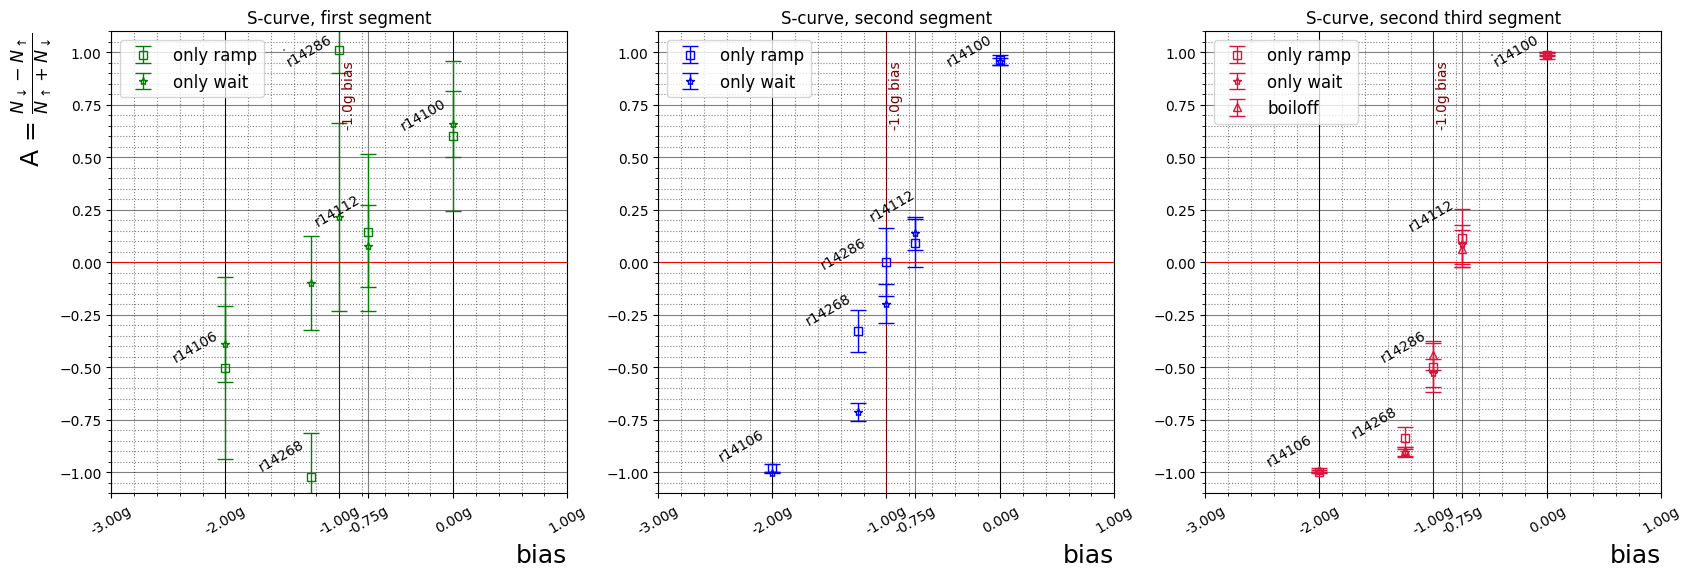

In [12]:
print("bias; S=Ndwn/(Ntot) ; dS")
for bias_, asymmetry, error in zip(bias, S, dS):
    print(f"| {bias_:.2f}g,\t  {asymmetry:.2f},\t {error:.2}")


plt.figure(1, figsize = (20, 6))
plt.subplot(1,3,1)
plt.title("S-curve, first segment")
plt.ylabel(r"A = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
plt.xlabel("bias", loc = 'right', fontsize = 18)

plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-1.1,1.1)
#plt.xlim(-3, 3)

#######
#plt.errorbar(biases_sim_830 - 1, simulation_830,    marker = "x", markersize = 5, linestyle = "--", color = "black", label = "sim OCT 830A")
#plt.errorbar(biases_sim_830 - 1, simulation_s6_830, marker = "x", markersize = 5, linestyle = "--", color = "green", label = "sim OCT 830A")
#plt.errorbar(biases_sim_830 - 1, simulation_s7_830, marker = "x", markersize = 5, linestyle = "--", color = "blue", label =  "sim OCT 830A")
#######

plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
#plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

plt.errorbar(bias, S_ramp1, dS_ramp1, marker = "s", markersize = 6, markerfacecolor='none', color = "green", capsize = 6, elinewidth=1, linestyle = "", label = "only ramp")
#plt.errorbar(bias, S_ramp1_wait, dS_ramp1_wait, marker = "^", markersize = 6, color = "green", capsize = 6, elinewidth=1, linestyle = "", label = "including wait")
plt.errorbar(bias, S_ramp1_onlywait, dS_ramp1_onlywait, marker = "*", markersize = 6, markerfacecolor='none', color = "green", capsize = 6, elinewidth=1, linestyle = "", label = "only wait")

labels = [-3, -2, -1, -.75,  0, 1]
plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

# metto una etichetta vicino a ogni punto
#for xi, yi, label in zip(bias, S, list_runs):
#    plt.text(xi-0.07, yi, label, fontsize=10, ha="right", va="bottom")

texts = []
for xi, yi, label in zip(bias, S_ramp1, list_runs):
    texts.append(plt.text(xi - 0.5, yi, label, rotation = 30))

adjust_text(texts, bias, S, arrowprops=dict(arrowstyle="->", color='gray'))

plt.legend(fontsize = 12)

#--------------------------------------------------------------
plt.subplot(1,3,2)
plt.title("S-curve, second segment")
#plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
plt.xlabel("bias", loc = 'right', fontsize = 18)

plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-1.1,1.1)
#plt.xlim(-3, 3)

plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
#plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

plt.errorbar(bias, S_ramp2, dS_ramp2, marker = "s", markersize = 6, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "", label = "only ramp")
#plt.errorbar(bias, S_ramp2_wait, dS_ramp2_wait, marker = "^", markersize = 6, color = "blue", capsize = 6, elinewidth=1, linestyle = "",  label = "including wait")
plt.errorbar(bias, S_ramp2_onlywait, dS_ramp2_onlywait, marker = "*", markersize = 6, markerfacecolor='none', color = "blue", capsize = 6, elinewidth=1, linestyle = "",  label = "only wait")

labels = [-3, -2, -1, -.75,  0, 1]
plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

# metto una etichetta vicino a ogni punto
#for xi, yi, label in zip(bias, S, list_runs):
#    plt.text(xi-0.07, yi, label, fontsize=10, ha="right", va="bottom")

texts = []
for xi, yi, label in zip(bias, S_ramp2, list_runs):
    texts.append(plt.text(xi - 0.5, yi, label, rotation = 30))

adjust_text(texts, bias, S, arrowprops=dict(arrowstyle="->", color='white'))

plt.legend(fontsize = 12)

#--------------------------------------------------------------
plt.subplot(1,3,3)
plt.title("S-curve, second third segment")
#plt.ylabel(r"S = $\frac{N_{\downarrow} - N_{\uparrow}}{N_{\uparrow} + N_{\downarrow}}$", fontsize = 18, loc = "top")
plt.xlabel("bias", loc = 'right', fontsize = 18)

plt.grid()
plt.minorticks_on()
plt.grid(which='major', linestyle='-', color='black', alpha = 0.5) #Griglia maggiore: linea continua nera
plt.grid(which='minor', linestyle=':', color='gray') #Griglia minore: linea tratteggiata grigia
plt.ylim(-1.1,1.1)

plt.axhline(0.0, linestyle = "-",  color = "red",    alpha = 1, linewidth = 0.75)
#plt.text(-2.9, 0.005, "balance escape 0.0", color = "red")
plt.axvline(0,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-2,   linestyle = "-",  color = "black",  linewidth = 0.75)
plt.axvline(-1,  linestyle = "-", color = "maroon", linewidth = 0.75)
plt.text( -1. + 0.02, 0.65, "-1.0g bias", rotation = 90, color = "maroon")

plt.errorbar(bias, S_ramp3, dS_ramp3, marker = "s", markersize = 6, markerfacecolor='none', color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "only ramp")
#plt.errorbar(bias, S_ramp3_wait, dS_ramp3_wait, marker = "^", markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "including wait")
plt.errorbar(bias, S_ramp3_onlywait, dS_ramp3_onlywait, marker = "*", markerfacecolor='none', markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "only wait")
plt.errorbar(bias, S_boiloff, dS_boiloff, marker = "^", markerfacecolor='none', markersize = 6, color = "crimson", capsize = 6, elinewidth=1, linestyle = "", label = "boiloff")

labels = [-3, -2, -1, -.75,  0, 1]
plt.xticks(labels,[f"{item:.2f}g" for item in labels], rotation = 30)      # etichette

# metto una etichetta vicino a ogni punto
#for xi, yi, label in zip(bias, S, list_runs):
#    plt.text(xi-0.07, yi, label, fontsize=10, ha="right", va="bottom")

texts = []
for xi, yi, label in zip(bias, S_ramp3, list_runs):
    texts.append(plt.text(xi - 0.5, yi, label, rotation = 30))

adjust_text(texts, bias, S, arrowprops=dict(arrowstyle="->", color='gray'))

plt.legend(fontsize = 12)

plt.savefig("S_curve.png", bbox_inches = 'tight')

In [19]:
with open("data.txt", "w") as file:
    file.write("#bias \t segment1 \t segment1_wait \t segment2 \t segment2_wait \t segment3 \t segment3_wait\n")
    for bias_, s1, s1_w, s2, s2_w, s3, s3_w in zip(bias, S_ramp1, S_ramp1_onlywait , S_ramp2, S_ramp2_onlywait, S_ramp3, S_ramp3_onlywait):
        file.write(f"{bias_:.2f} \t {s1:.2f} \t {s1_w:.2f} \t {s2:.2f} \t {s2_w:.2f} \t {s3:.2f} \t {s3_w:.2f}\n")

In [14]:
mirG_center = -415
mirA_center = -671
zmin = mirA_center - 200
zgap_min = mirA_center
zmax = mirG_center + 200
zgap_max = mirG_center
CutsType = "CutsType2"

class Zcuts:
    def __init__(self,a,b):
        self.mirG_center = a
        self.mirA_center = b
        self.zmin = b - 200
        self.zmax = a + 200
        self.zgap_min = b
        self.zgap_max = a

ZCUTS = Zcuts(-415,-671)

# Z distribution comparison

In [15]:
dataset_2023 = pd.read_csv("../../ag-easy/BKF/bkf_MAGB0.vertex.csv", delimiter = ',')
runToKey = {}
keyToRuns = {}
for l in open('../../ag-easy/BKF/bkf.maps').readlines():
    run, key  = l.split()
    runToKey.update({int(run):int(key)})
    try:
        runs = keyToRuns[int(key)]
    except:
        runs = []        
    runs.append(int(run))
    keyToRuns.update({int(key):runs})

for key, item in runToKey.items():
    print(f"key/run {key}; value {item}")
#print(runToKey)

key/run 9677; value 101
key/run 9691; value 101
key/run 9671; value 101
key/run 9663; value 101
key/run 9696; value 101
key/run 9658; value 101
key/run 9382; value 100
key/run 9392; value 100
key/run 9408; value 100
key/run 9422; value 100
key/run 9412; value 100
key/run 9384; value 100
key/run 9634; value 30
key/run 9614; value 30
key/run 9622; value 30
key/run 9672; value 30
key/run 9586; value 30
key/run 9618; value 30
key/run 9595; value 30
key/run 9647; value 20
key/run 9668; value 20
key/run 9502; value 20
key/run 9461; value 20
key/run 9566; value 20
key/run 9561; value 20
key/run 9571; value 20
key/run 9513; value 10
key/run 9664; value 10
key/run 9569; value 10
key/run 9558; value 10
key/run 9503; value 10
key/run 9464; value 10
key/run 9471; value 10
key/run 9702; value 15
key/run 9713; value 15
key/run 9724; value 15
key/run 9728; value 15
key/run 9718; value 15
key/run 9732; value 15
key/run 9644; value 5
key/run 9630; value 5
key/run 9687; value 5
key/run 9616; value 5
key

In [16]:
from Utils import ReadTheCsv,ReadTheSpill,append_to_dict

#----------------------
dataset_2025_1 = ReadTheCsv("../v1/ag14100/ag14100.vertex.csv","-1", zmin, zmax, CutsType)
dataset_2025_2 = ReadTheCsv("../v1/ag14106/ag14106.vertex.csv","-1", zmin, zmax, CutsType)

dataset_2025 = pd.concat([dataset_2025_1, dataset_2025_2], axis=0)

ag14100/ag14100.vertex.csv
   [26640.301-26740.304]= 100.003s |          "WaitForQuasitrapped"[0]    |   10556      507      530      349     5310     3878    12216     7721    20590        38 

ag14100/ag14100.vertex.csv
   [27249.259-27849.266]= 600.008s |          "WaitForQuasitrapped"[1]    |   63267     3287     3233     2072    32031    23689    73469    45788   124065       378 

ag14100/ag14100.vertex.csv
   [26850.997-26862.199]=  11.202s |          "MBMF RampDown"[0]          |    1074       61       53       29      499      396     1214      852     1931         6 

ag14100/ag14100.vertex.csv
   [26983.913-26995.115]=  11.202s |          "MBMF RampDown"[1]          |    1148       51       53       31      545      420     1317     1208     2690       116 

ag14100/ag14100.vertex.csv
   [27116.943-27128.146]=  11.202s |          "MBMF RampDown"[2]          |    1104       56       55       42      545      447     1307     1285     2653       142 

ag14106/ag14106.vertex.cs

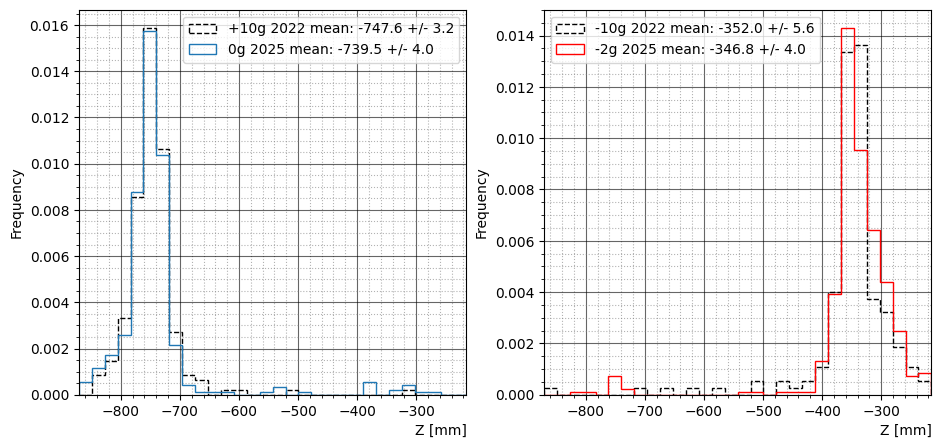

In [17]:
plt.figure(figsize = (11, 5))
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2)

mask = (dataset_2023["CutsType7"] == 1) & ((dataset_2023["Run Number"].map(runToKey) == 101)) & (dataset_2023["Z"] > ZCUTS.zmin) & ( dataset_2023["Z"] < ZCUTS.zmax)

dataset_2023["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"+10g 2022 mean: { dataset_2023['Z'][mask].mean():.4} +/- {dataset_2023['Z'][mask].std()/np.sqrt(dataset_2023['Z'][mask].size):.2}",
                             density = True,
                             ax = ax1)

mask = (dataset_2023["CutsType7"] == 1) & ((dataset_2023["Run Number"].map(runToKey) == -101)) & (dataset_2023["Z"] > ZCUTS.zmin) & ( dataset_2023["Z"] < ZCUTS.zmax)

dataset_2023["Z"][mask].plot(kind = 'hist',
                             bins = 30,
                             range = [zmin, zmax],
                             histtype = 'step',
                             linestyle = "--",
                             color = 'black',
                             label = f"-10g 2022 mean: {dataset_2023['Z'][mask].mean():.4} +/- {dataset_2023['Z'][mask].std()/np.sqrt(dataset_2023['Z'][mask].size):.2}",
                             density = True,
                             ax = ax2)

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("ag14100/ag14100.vertex.csv", "\"WaitForQuasitrapped\"[1]")
# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("ag14100/ag14100.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14100) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"0g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         density = True,
                                         ax = ax1)

# WaitForQuasitrapped, or boil off
waitForQuasiTrapped_start, waitForQuasiTrapped_stop = ReadTheSpill("ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[0]")
waitForQuasiTrapped_start1, waitForQuasiTrapped_stop1 = ReadTheSpill("ag14106/ag14106.vertex.csv", "\"WaitForQuasitrapped\"[1]")

# Three Segment Ramp Down
start_mbmf_rampdown0, stop_mbmf_rampdown0 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[0]")
start_mbmf_rampdown1, stop_mbmf_rampdown1 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[1]")
start_mbmf_rampdown2, stop_mbmf_rampdown2 = ReadTheSpill("ag14106/ag14106.vertex.csv","\"MBMF RampDown\"[2]")

mask      = (dataset_2025[CutsType] == 1) & (dataset_2025["Run Number"] == 14106) & (dataset_2025["Z"] > ZCUTS.zmin) & ( dataset_2025["Z"] < ZCUTS.zmax)
mask_time = ((dataset_2025["run time"] > start_mbmf_rampdown0[0]) & (dataset_2025["run time"] < start_mbmf_rampdown2[0]))

dataset_2025["Z"][mask & mask_time].plot(kind = 'hist',
                                         bins = 30,
                                         range = [zmin, zmax],
                                         histtype = 'step',
                                         label = f"-2g 2025 mean: {dataset_2025['Z'][mask & mask_time].mean():.4} +/- {dataset_2025['Z'][mask & mask_time].std() / np.sqrt(dataset_2025['Z'][mask & mask_time].size):.2}",
                                         color = "red",
                                         density = True,
                                         ax = ax2)

ax2.minorticks_on()
ax2.set_xlim(zmin, zmax)
ax2.set_xlabel("Z [mm]",loc = "right")
ax2.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax2.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax2.legend()

ax1.minorticks_on()
ax1.set_xlim(zmin, zmax)
ax1.set_xlabel("Z [mm]",loc = "right")
ax1.grid(which='major', linestyle='-', color='black', alpha = 0.6) #Griglia maggiore: linea continua nera
ax1.grid(which='minor', linestyle=':', color='gray', alpha = 0.6) #Griglia minore: linea tratteggiata grigia
ax1.legend()
plt.savefig("Zpdf_comparison.png", bbox_inches = 'tight')